# Chat metrics notebook

See [evals/README.md](README.md) for the full eval workflow and related notebooks.

**TL;DR.** This notebook compares the **RAG Agent** and the **Research Agent** (the Research Agent uses Google web search) on the same five conversations and model (`gemini-2.5-flash`).

**LLM-judge:** Both approaches **score** very similarly: strong **correctness** and **clarity**, aligned **completeness**, with **slightly lower usefulness for the RAG Agent**.

**Runtime & cost:** The **RAG Agent** is **faster on average**. Its **p90 latency** is **23.3% lower** than the Research Agent's (turn-level, this sample). **Total tokens** for the RAG Agent are **+23.4%** relative to the Research Agent.

**Bottom line:** There is no clear quality winner; prefer **RAG** if latency matters most, **Research** if you want to **cut token usage**.

### Imports

In [1]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))

from utils.config import DATA_FOLDER, CONVERSATION_PATH, CONVERSATION_PATH_V2

LATENCY_COMPARE_PNG = DATA_FOLDER / "conversation_metrics_latency_compare.png"
CHAT_EVALUATIONS_PATH = DATA_FOLDER / "chat_evaluations.json"

### Auxiliary functions

In [2]:
def conversation_overview(conversations: list) -> dict:
    n_conversations = len(conversations)
    models = sorted({c["model_name"] for c in conversations})
    models_str = ", ".join(models)
    total_tokens = sum(sum(c["total_tokens"]) for c in conversations)
    total_turns = sum(c["turns"] for c in conversations)
    all_latencies: list[float] = []

    for c in conversations:
        all_latencies.extend(float(x) for x in c["latency"])

    mean_latency = float(np.mean(all_latencies)) if all_latencies else 0.0
    p90_latency_s = float(np.percentile(all_latencies, 90)) if all_latencies else 0.0
    role_counts: Counter[str] = Counter()

    for conv in conversations:
        for msg in conv["chat"]:
            role_counts[msg.get("role", "(no role)")] += 1

    return {
        "n_conversations": n_conversations,
        "models_str": models_str,
        "total_tokens": total_tokens,
        "total_turns": total_turns,
        "mean_latency_s": mean_latency,
        "p90_latency_s": p90_latency_s,
        "role_counts": dict(role_counts),
        "all_latencies": all_latencies,
    }
    
def _fmt_int(n: int) -> str:
    return f"{n:,}".replace(",", ".")

### Main metrics

In [3]:
ov1 = conversation_overview(json.loads(CONVERSATION_PATH.read_text(encoding="utf-8")))
ov2 = conversation_overview(json.loads(CONVERSATION_PATH_V2.read_text(encoding="utf-8")))

label_v1 = "Research Agent"
label_v2 = "RAG Agent"

compare_df = pd.DataFrame(
    {
        label_v1: [
            ov1["n_conversations"],
            ov1["total_tokens"],
            ov1["total_turns"],
            f"{ov1['mean_latency_s']:.2f}",
            f"{ov1['p90_latency_s']:.2f}",
            ov1['models_str']
        ],
        label_v2: [
            ov2["n_conversations"],
            ov2["total_tokens"],
            ov2["total_turns"],
            f"{ov2['mean_latency_s']:.2f}",
            f"{ov2['p90_latency_s']:.2f}",
            ov2['models_str']
        ],
    },
    index=[
        "Number of conversations",
        "Total tokens",
        "Total turns",
        "Mean latency (s)",
        "P90 latency (s)",
        "Model class",
    ],
)
display(compare_df)

all_roles = sorted(set(ov1["role_counts"]) | set(ov2["role_counts"]))
role_df = pd.DataFrame(
    {
        label_v1: [ov1["role_counts"].get(r, 0) for r in all_roles],
        label_v2: [ov2["role_counts"].get(r, 0) for r in all_roles],
    },
    index=all_roles,
)
role_df.index.name = "role"
display(role_df)

,Research Agent,RAG Agent
Number of conversations,5,5
Total tokens,100424,123933
Total turns,26,26
Mean latency (s),5.17,4.61
P90 latency (s),16.75,12.85
Model class,gemini-2.5-flash,gemini-2.5-flash


,Research Agent,RAG Agent
role,,
planner_agent,34,37
pricing_agent,2,5
rag_agent,0,6
research_agent,5,0
user,26,26


### Latency comparison

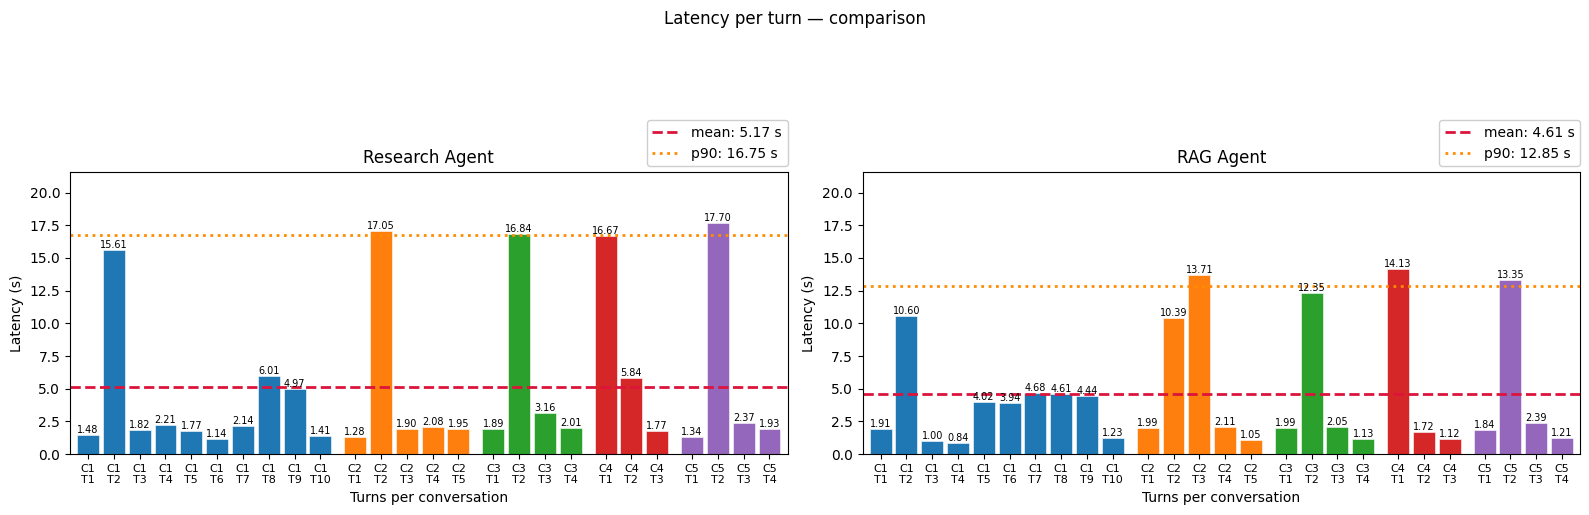

Figure saved to: /Users/vinicius.araujo/Github/genai/data/conversation_metrics_latency_compare.png


In [4]:
def plot_latency_bars(ax, conversations: list, title: str) -> None:
    gap = 0.35
    x_cursor = 0.0
    x_positions: list[float] = []
    x_labels: list[str] = []
    all_latencies: list[float] = []

    for i, conv in enumerate(conversations):
        lats = [float(x) for x in conv["latency"]]
        all_latencies.extend(lats)
        color = f"C{i}"
        for j, lat in enumerate(lats, start=1):
            ax.bar(
                x_cursor,
                lat,
                width=0.85,
                color=color,
                edgecolor="white",
                linewidth=0.4,
            )
            ax.text(
                x_cursor,
                lat,
                f"{lat:.2f}",
                ha="center",
                va="bottom",
                fontsize=7,
            )
            x_labels.append(f"C{i + 1}\nT{j}")
            x_positions.append(x_cursor)
            x_cursor += 1.0
        x_cursor += gap

    mean_latency = float(np.mean(all_latencies)) if all_latencies else 0.0
    p90_latency = float(np.percentile(all_latencies, 90)) if all_latencies else 0.0

    ax.axhline(
        mean_latency,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"mean: {mean_latency:.2f} s",
    )
    ax.axhline(
        p90_latency,
        color="darkorange",
        linestyle=":",
        linewidth=2,
        label=f"p90: {p90_latency:.2f} s",
    )
    ax.set_ylabel("Latency (s)")
    ax.set_xlabel("Turns per conversation")
    ax.set_title(title)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.legend(
        loc="lower right",
        bbox_to_anchor=(1.0, 1.02),
        borderaxespad=0,
        framealpha=0.95,
    )
    ax.margins(x=0.01)


fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5))
plot_latency_bars(ax_left, json.loads(CONVERSATION_PATH.read_text(encoding="utf-8")), label_v1)
plot_latency_bars(ax_right, json.loads(CONVERSATION_PATH_V2.read_text(encoding="utf-8")), label_v2)

ymax_candidates: list[float] = []
for ov in (ov1, ov2):
    ymax_candidates.extend(ov["all_latencies"])
    if ov["all_latencies"]:
        ymax_candidates.append(ov["mean_latency_s"])
        ymax_candidates.append(float(np.percentile(ov["all_latencies"], 90)))
ymax = max(ymax_candidates) if ymax_candidates else 1.0
ax_left.set_ylim(0, ymax * 1.22)
ax_right.set_ylim(0, ymax * 1.22)

fig.suptitle("Latency per turn — comparison", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(LATENCY_COMPARE_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {LATENCY_COMPARE_PNG}")

### Qualitative evaluation (LLM judge)

In [5]:
raw_eval = json.loads(CHAT_EVALUATIONS_PATH.read_text(encoding="utf-8"))
score_dims = ["correctness", "completeness", "clarity", "usefulness"]
rows: list[dict] = []
for r in raw_eval:
    row = {"approach": r["approach"]}
    for k in score_dims:
        row[k] = r["scores"][k]
    rows.append(row)
eval_df = pd.DataFrame(rows)

order = [label_v1, label_v2]
# Per-dimension means by approach; overall = mean of those dimension means (not per conversation).
eval_means = eval_df.groupby("approach")[score_dims].mean().reindex(order)
eval_means["overall_score"] = eval_means[score_dims].mean(axis=1)

rename_eval = {
    "correctness": "Correctness",
    "completeness": "Completeness",
    "clarity": "Clarity",
    "usefulness": "Usefulness",
    "overall_score": "Overall score",
}
eval_means = eval_means.rename(columns=rename_eval)
eval_means.index.name = "Approach"

display(eval_means.T.round(3))

Approach,Research Agent,RAG Agent
Correctness,5.00,5.0
Completeness,4.00,4.0
Clarity,5.00,5.0
Usefulness,4.60,4.4
Overall score,4.65,4.6


In [6]:
img_name = LATENCY_COMPARE_PNG.name

md_lines = [
    "# Conversation metrics report",
    "",
    "**TL;DR.** This report compares the **RAG Agent** and the **Research Agent** (the Research Agent uses Google web search) on the same five conversations and model (`gemini-2.5-flash`).",
    "",
    "**LLM-judge:** Both approaches **score** very similarly: strong **correctness** and **clarity**, aligned **completeness**, with **slightly lower usefulness for the RAG Agent**.",
    "",
    "**Runtime & cost:** The **RAG Agent** is **faster on average**. Its **p90 latency** is **23.3% lower** than the Research Agent's (turn-level, this sample). **Total tokens** for the RAG Agent are **+23.4%** relative to the Research Agent.",
    "",
    "**Bottom line:** There is no clear quality winner; prefer **RAG** if latency matters most, **Research** if you want to **cut token usage**.",
    "",
    "---",
    "",
    "Comparison between `Research Agent` and `RAG Agent` (detail in the tables below).",
    "",
    "## 1. Overview — comparison",
    "",
    "| Metric | Research Agent | RAG Agent |",
    "| --- | ---: | ---: |",
    f"| Number of conversations | {_fmt_int(ov1['n_conversations'])} | {_fmt_int(ov2['n_conversations'])} |",
    f"| Total tokens | {_fmt_int(ov1['total_tokens'])} | {_fmt_int(ov2['total_tokens'])} |",
    f"| Total turns | {_fmt_int(ov1['total_turns'])} | {_fmt_int(ov2['total_turns'])} |",
    f"| Mean latency (s) | {ov1['mean_latency_s']:.2f} | {ov2['mean_latency_s']:.2f} |",
    f"| P90 latency (s) | {ov1['p90_latency_s']:.2f} | {ov2['p90_latency_s']:.2f} |",
    f"| Model class | {ov1['models_str']} | {ov2['models_str']} |",
    "",
    "### Messages by `role`",
    "",
    "| role | Research Agent | RAG Agent |",
    "| --- | ---: | ---: |",
]

for role in all_roles:
    md_lines.append(
        f"| `{role}` | {_fmt_int(ov1['role_counts'].get(role, 0))} | "
        f"{_fmt_int(ov2['role_counts'].get(role, 0))} |"
    )

md_lines.extend(
    [
        "",
        "## 2. Latency",
        "",
        f"![Latency per turn — side-by-side comparison]({img_name})",
        "",
    ]
)

md_lines.extend(
    [
        "",
        "## 3. Qualitative evaluation (LLM as judge)",
        "",
        "| Criterion | Research Agent | RAG Agent |",
        "| --- | ---: | ---: |",
    ]
)
for col in eval_means.columns:
    md_lines.append(
        f"| {col} | {eval_means.loc[label_v1, col]:.2f} | {eval_means.loc[label_v2, col]:.2f} |"
    )
md_lines.append("")

(DATA_FOLDER / "conversation_metrics_report.md").write_text("\n".join(md_lines), encoding="utf-8")
print(f"Markdown saved to: {(DATA_FOLDER / "conversation_metrics_report.md")}")

Markdown saved to: /Users/vinicius.araujo/Github/genai/data/conversation_metrics_report.md
